In [46]:
import numpy 
import numba
import numpy as np
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pystormtracker as pst

In [47]:
tracker = pst.HodgesTracker()

In [48]:
file_loc_01020304 = "f19a177154e1f391965054b2bed72f43.nc"

data_anatol = xr.open_dataset(file_loc_01020304)

In [49]:
data_anatol

<xarray.Dataset> Size: 133MB
Dimensions:         (valid_time: 16, pressure_level: 1, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 128B 1999-12-02 ... 1999-12-0...
    expver          (valid_time) <U4 256B ...
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 66MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 66MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-15T13:55 GRIB to CDM+CF via cfgrib-0.9.1...

In [50]:
data_anatol['latitude'].values


array([ 90.  ,  89.75,  89.5 ,  89.25,  89.  ,  88.75,  88.5 ,  88.25,
        88.  ,  87.75,  87.5 ,  87.25,  87.  ,  86.75,  86.5 ,  86.25,
        86.  ,  85.75,  85.5 ,  85.25,  85.  ,  84.75,  84.5 ,  84.25,
        84.  ,  83.75,  83.5 ,  83.25,  83.  ,  82.75,  82.5 ,  82.25,
        82.  ,  81.75,  81.5 ,  81.25,  81.  ,  80.75,  80.5 ,  80.25,
        80.  ,  79.75,  79.5 ,  79.25,  79.  ,  78.75,  78.5 ,  78.25,
        78.  ,  77.75,  77.5 ,  77.25,  77.  ,  76.75,  76.5 ,  76.25,
        76.  ,  75.75,  75.5 ,  75.25,  75.  ,  74.75,  74.5 ,  74.25,
        74.  ,  73.75,  73.5 ,  73.25,  73.  ,  72.75,  72.5 ,  72.25,
        72.  ,  71.75,  71.5 ,  71.25,  71.  ,  70.75,  70.5 ,  70.25,
        70.  ,  69.75,  69.5 ,  69.25,  69.  ,  68.75,  68.5 ,  68.25,
        68.  ,  67.75,  67.5 ,  67.25,  67.  ,  66.75,  66.5 ,  66.25,
        66.  ,  65.75,  65.5 ,  65.25,  65.  ,  64.75,  64.5 ,  64.25,
        64.  ,  63.75,  63.5 ,  63.25,  63.  ,  62.75,  62.5 ,  62.25,
      

In [51]:
pst.preprocessing.kinematics.compute_vorticity_divergence?

Signature:
pst.preprocessing.kinematics.compute_vorticity_divergence(
    u: 'xr.DataArray | NDArray[np.float64]',
    v: 'xr.DataArray | NDArray[np.float64]',
    *,
    R: 'float' = 6371220.0,
    lmax: 'int | None' = None,
    geometry: 'str' = 'CC',
    nthreads: 'int' = 0,
    lat_reverse: 'bool' = False,
    backend: 'Backend' = 'serial',
) -> 'tuple[xr.DataArray | NDArray[np.float64], xr.DataArray | NDArray[np.float64]]'
Docstring:
Computes spatial divergence and relative vorticity from u and v wind components.
Accepts either a pair of xarray DataArrays or a pair of 2D NumPy arrays.

Args:
    u: Zonal wind component (DataArray or 2D NumPy array).
    v: Meridional wind component (DataArray or 2D NumPy array).
    R: Planetary radius in meters. Default is R_EARTH_M.
    lmax: Maximum spherical harmonic degree.
    geometry: Grid geometry ('CC', 'DH', etc.). Default 'CC'.
    nthreads: Number of threads.
    lat_reverse: If True, assume latitude is North to South (NumPy only).
  

In [52]:
div, vort = pst.preprocessing.kinematics.compute_vorticity_divergence(data_anatol['u'], data_anatol['v'])

In [53]:
vort

<xarray.DataArray 'relative_vorticity' (valid_time: 16, pressure_level: 1,
                                        latitude: 721, longitude: 1440)> Size: 66MB
array([[[[ 1.9602574e-05,  1.9602574e-05,  1.9602574e-05, ...,
           1.9602574e-05,  1.9602574e-05,  1.9602574e-05],
         [-3.9773434e-04, -3.9748411e-04, -3.9722299e-04, ...,
          -3.9841977e-04, -3.9820219e-04, -3.9797369e-04],
         [-1.2706438e-04, -1.2700674e-04, -1.2694340e-04, ...,
          -1.2720325e-04, -1.2716262e-04, -1.2711635e-04],
         ...,
         [ 6.6792403e-05,  6.6952685e-05,  6.7112378e-05, ...,
           6.6308065e-05,  6.6470086e-05,  6.6631532e-05],
         [ 4.9804634e-04,  4.9906579e-04,  5.0007703e-04, ...,
           4.9493910e-04,  4.9598300e-04,  4.9701874e-04],
         [-1.7005186e-05, -1.7005186e-05, -1.7005186e-05, ...,
          -1.7005186e-05, -1.7005186e-05, -1.7005186e-05]]],


       [[[ 2.3893559e-05,  2.3893559e-05,  2.3893559e-05, ...,
           2.3893559e-05,  2.3893559e-05,  2.3893559e-05],
         [-4.2005358e-04, -4.1989013e-04, -4.1971539e-04, ...,
          -4.2047611e-04, -4.2034659e-04, -4.2020573e-04],
         [-1.2959192e-04, -1.2947540e-04, -1.2935327e-04, ...,
...
         [ 5.7369511e-04,  5.7308358e-04,  5.7245756e-04, ...,
           5.7544257e-04,  5.7487463e-04,  5.7429215e-04],
         [-2.0044499e-05, -2.0044499e-05, -2.0044499e-05, ...,
          -2.0044499e-05, -2.0044499e-05, -2.0044499e-05]]],


       [[[-3.0955357e-06, -3.0955357e-06, -3.0955357e-06, ...,
          -3.0955357e-06, -3.0955357e-06, -3.0955357e-06],
         [ 2.9888813e-04,  3.0030814e-04,  3.0172640e-04, ...,
           2.9461799e-04,  2.9604306e-04,  2.9746644e-04],
         [-1.7557037e-05, -1.7580705e-05, -1.7598963e-05, ...,
          -1.7454387e-05, -1.7493796e-05, -1.7528040e-05],
         ...,
         [ 1.4022007e-04,  1.3969160e-04,  1.3916020e-04, ...,
           1.4178734e-04,  1.4126801e-04,  1.4074557e-04],
         [ 5.8980164e-04,  5.8820751e-04,  5.8660062e-04, ...,
           5.9450750e-04,  5.9295166e-04,  5.9138302e-04],
         [ 2.2176928e-05,  2.2176928e-05,  2.2176928e-05, ...,
           2.2176928e-05,  2.2176928e-05,  2.2176928e-05]]]],
      shape=(16, 1, 721, 1440), dtype=float32)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 128B 1999-12-02 ... 1999-12-0...
    expver          (valid_time) <U4 256B '0001' '0001' '0001' ... '0001' '0001'
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B 0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

In [54]:
lat_s, lat_n = -90.0, 90.0        
lon_w, lon_e = -180.0, 180.0

vor = (
    vort.squeeze("pressure_level", drop=True)
        .drop_vars(["expver", "number"], errors="ignore")
        .rename({"valid_time": "time"})
        .assign_coords(longitude=((vort.longitude + 180) % 360) - 180)   # 0–360 -> -180–180
        .sortby("longitude")
        .sel(latitude=slice(lat_n, lat_s), longitude=slice(lon_w, lon_e))  # lat is descending
        .transpose("time", "latitude", "longitude")
        .rename("vo")
)

In [55]:
vor

<xarray.DataArray 'vo' (time: 16, latitude: 721, longitude: 1440)> Size: 66MB
array([[[ 1.96025740e-05,  1.96025740e-05,  1.96025740e-05, ...,
          1.96025740e-05,  1.96025740e-05,  1.96025740e-05],
        [ 3.59080528e-04,  3.59119615e-04,  3.59151687e-04, ...,
          3.58920865e-04,  3.58981139e-04,  3.59034340e-04],
        [ 5.26391123e-05,  5.25008145e-05,  5.23558629e-05, ...,
          5.30133584e-05,  5.28954515e-05,  5.27706798e-05],
        ...,
        [-2.04641605e-04, -2.04871103e-04, -2.05090531e-04, ...,
         -2.03892501e-04, -2.04152311e-04, -2.04402008e-04],
        [-6.13687036e-04, -6.14892342e-04, -6.16082572e-04, ...,
         -6.09981362e-04, -6.11231546e-04, -6.12466771e-04],
        [-1.70051862e-05, -1.70051862e-05, -1.70051862e-05, ...,
         -1.70051862e-05, -1.70051862e-05, -1.70051862e-05]],

       [[ 2.38935590e-05,  2.38935590e-05,  2.38935590e-05, ...,
          2.38935590e-05,  2.38935590e-05,  2.38935590e-05],
        [ 3.93304334e-04,  3.93497554e-04,  3.93682654e-04, ...,
          3.92676069e-04,  3.92893591e-04,  3.93103022e-04],
        [ 6.52000599e-05,  6.50977599e-05,  6.49873618e-05, ...,
          6.54575779e-05,  6.53800453e-05,  6.52941817e-05],
...
         -4.18331365e-05, -4.24472819e-05, -4.30624277e-05],
        [-4.88277612e-04, -4.87948535e-04, -4.87613695e-04, ...,
         -4.89230442e-04, -4.88918507e-04, -4.88600926e-04],
        [-2.00444993e-05, -2.00444993e-05, -2.00444993e-05, ...,
         -2.00444993e-05, -2.00444993e-05, -2.00444993e-05]],

       [[-3.09553570e-06, -3.09553570e-06, -3.09553570e-06, ...,
         -3.09553570e-06, -3.09553570e-06, -3.09553570e-06],
        [-4.12951980e-04, -4.13911475e-04, -4.14861017e-04, ...,
         -4.10013716e-04, -4.11003130e-04, -4.11982532e-04],
        [-8.49534699e-05, -8.44972892e-05, -8.40413777e-05, ...,
         -8.63234163e-05, -8.58665517e-05, -8.54098980e-05],
        ...,
        [-3.31066258e-05, -3.30847761e-05, -3.30628463e-05, ...,
         -3.31717565e-05, -3.31501105e-05, -3.31284027e-05],
        [-4.81926749e-04, -4.80681425e-04, -4.79428476e-04, ...,
         -4.85616998e-04, -4.84394550e-04, -4.83164476e-04],
        [ 2.21769278e-05,  2.21769278e-05,  2.21769278e-05, ...,
          2.21769278e-05,  2.21769278e-05,  2.21769278e-05]]],
      shape=(16, 721, 1440), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 128B 1999-12-02 ... 1999-12-05T18:00:00
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number     int64 8B 0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

In [59]:
vor.attrs = {"units": "s^-1", "long_name": "relative vorticity"}
print(vor.attrs)

{'units': 's^-1', 'long_name': 'relative vorticity'}


In [61]:
tracker = pst.HodgesTracker(min_track_points=8, taper_points=10, lmin=5, lmax=42)        
tracks = tracker.track(
    vor.to_dataset(name='vo'),
    "vo",
    detection_mode="max", 
    #object_threshold=2e-5
    
)

for track in tracks:
    if len(track) >= 8:
        print(track.track_id, len(track))

tracks.write("tracks.trackjson")

1 16
3 14
9 12
10 16
23 16
31 13
35 16
45 16
53 10
63 16
69 16
75 9
87 15
113 12
121 13
125 9
129 8
131 11
133 16
137 10
145 16
147 13
153 11
157 8
167 14
181 8
183 8
195 9
209 9
213 11
227 9
231 9
243 16
247 16
251 16
255 8
261 12
271 13
275 14
281 16
283 9
291 16
295 11
297 16
299 13
301 8
309 10
331 11
339 9
341 12
345 16
347 16
349 10
351 8
357 8
359 16
361 14
365 16
381 16
387 10
391 12
399 12
421 13
423 8
439 15
491 9
497 10
527 11
535 10
555 13
565 13
577 13
593 8
595 12
605 10
611 10
613 8
615 9
617 12
621 12
623 12
633 11
639 11
643 12
649 12
661 11
677 9
689 11
693 9
699 8
727 10
767 10
777 10
783 8
791 8
795 9
799 9
841 9
845 8
865 8
911 8
917 8
925 8
1431 11
1433 15
1437 10
1441 16
1449 15
1451 8
1489 12
1499 11
1545 10
1615 8
1649 9
1671 8
1683 8
1685 10
1701 16
1703 10
1723 10
1725 13
1727 16
1731 8
1737 9
1739 9
1741 12
1743 11
1745 8
1747 12


In [62]:
first = next(iter(tracks))
print(type(first), [a for a in dir(first) if not a.startswith("_")])


<class 'pystormtracker.models.tracks.Track'> ['abs_dist', 'lats', 'lons', 'point_slice', 'times', 'track_id', 'variables']


/usr/local/Caskroom/miniconda/base/envs/pystormtracker/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/pystormtracker/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/pystormtracker/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/pystormtracker/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/pyst

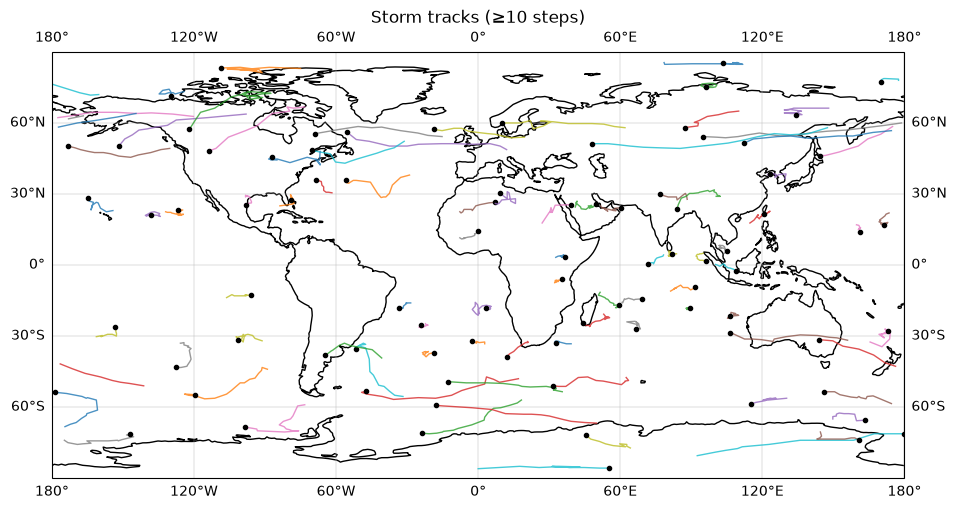

In [63]:
def split_at_dateline(lons, lats):
    """Insert NaNs where a track jumps across the 0/360 or ±180 seam."""
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)
    jumps = np.where(np.abs(np.diff(lons)) > 180)[0] + 1
    return np.insert(lons, jumps, np.nan), np.insert(lats, jumps, np.nan)

min_len = 10  # drop short-lived features

fig = plt.figure(figsize=(11, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.3)

for track in tracks:
    if len(track) < min_len:
        continue
    lons, lats = split_at_dateline(track.lons, track.lats)
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), lw=1, alpha=0.8)
    ax.plot(lons[0], lats[0], "o", ms=3, color="k", transform=ccrs.PlateCarree())  # genesis point

ax.set_title(f"Storm tracks (≥{min_len} steps)")
plt.savefig("tracks.png", dpi=150, bbox_inches="tight")
plt.show()